# KoopSim Speed Showdown: Train Once, Predict Instantly

**The pitch:** Traditional simulators solve ODEs step-by-step. KoopSim learns a linear operator from data, then predicts at *any* future time via a single matrix operation. No loops. No time-stepping. Just math.

**This notebook proves it.** We'll:
1. Race KoopSim against `scipy.integrate.solve_ivp` on three systems
2. Predict the **Lorenz attractor** (chaos!) in 3D
3. Let **auto-tuning** pick the best model automatically
4. Show predictions **1,000 steps into the future** computed in microseconds

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import solve_ivp

from koopsim import KoopSim
from koopsim.systems import (
    HopfBifurcation,
    LorenzAttractor,
    LotkaVolterra,
    RLCCircuit,
)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
print("Ready.")

Ready.


---
## Part 1: The Speed Race — Single-Point Prediction

The key insight: traditional solvers must **step through all intermediate times** to reach a future state. KoopSim jumps directly to any time `t` via matrix exponential. The further into the future you predict, the bigger the advantage.

We'll predict the state at `t = 10.0` (1,000 steps at dt=0.01) with both approaches.

In [2]:
# --- Setup: 4 systems of increasing complexity ---
systems = {
    "RLC Circuit\n(linear, 2D)": (RLCCircuit(R=1.0, L=1.0, C=0.5), np.array([1.0, 0.0])),
    "Lotka-Volterra\n(predator-prey, 2D)": (LotkaVolterra(), np.array([2.0, 1.0])),
    "Hopf Bifurcation\n(limit cycle, 2D)": (HopfBifurcation(mu=1.0), np.array([0.5, 0.0])),
    "Lorenz Attractor\n(chaos, 3D)": (LorenzAttractor(), np.array([1.0, 1.0, 1.0])),
}

dt = 0.01
n_pred_steps = 1000
pred_times = np.arange(1, n_pred_steps + 1) * dt

# Train KoopSim on each system
trained = {}
for name, (system, x0) in systems.items():
    X, Y = system.generate_snapshots(x0, dt=dt, n_steps=200, n_trajectories=10)
    sim = KoopSim(method="edmd", poly_degree=3, verbose=False)
    sim.fit(X, Y, dt=dt)
    trained[name] = (sim, system, x0)

print(f"Trained {len(trained)} models. Now racing...")

Generating RLCCircuit trajectories:   0%|          | 0/10 [00:00<?, ?it/s]

Generating RLCCircuit trajectories: 100%|██████████| 10/10 [00:00<00:00, 201.20it/s]

Generating LotkaVolterra trajectories:   0%|          | 0/10 [00:00<?, ?it/s]

Generating LotkaVolterra trajectories: 100%|██████████| 10/10 [00:00<00:00, 311.22it/s]


/home/yossi/work/orbit/koopsim/koopsim.py:182: UserWarning: Koopman matrix has 8 eigenvalue(s) with |lambda| > 1.000001 (max |lambda| = 1.016872). Predictions may diverge for large t.
  self._engine = PredictionEngine(self._model, method=self.prediction_method)
Unstable eigenvalues detected: 8 modes with max |lambda| = 1.016872.


...

Generating LorenzAttractor trajectories:  40%|████      | 4/10 [00:00<00:00, 31.94it/s]

Generating LorenzAttractor trajectories:  80%|████████  | 8/10 [00:00<00:00, 35.65it/s]

Generating LorenzAttractor trajectories: 100%|██████████| 10/10 [00:00<00:00, 36.01it/s]


/home/yossi/work/orbit/koopsim/koopsim.py:182: UserWarning: Koopman matrix has 5 eigenvalue(s) with |lambda| > 1.000001 (max |lambda| = 1.001434). Predictions may diverge for large t.
  self._engine = PredictionEngine(self._model, method=self.prediction_method)
Unstable eigenvalues detected: 5 modes with max |lambda| = 1.001434.


Trained 4 models. Now racing...


In [3]:
# --- THE RACE: predict state at t=10.0 (single point, 1000 steps away) ---
results = {}
t_target = 10.0
n_repeats = 200

for name, (sim, system, x0) in trained.items():
    # Traditional: solve_ivp must step through [0, 10.0]
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        sol = solve_ivp(system.rhs, [0, t_target], x0,
                        method="RK45", rtol=1e-8, atol=1e-10)
    t_trad = (time.perf_counter() - t0) / n_repeats

    # KoopSim: single matrix exponential — jumps straight to t=10.0
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        state_koop = sim.predict(x0, t=t_target)
    t_koop = (time.perf_counter() - t0) / n_repeats

    speedup = t_trad / t_koop
    results[name] = {
        "traditional_us": t_trad * 1e6,
        "koopsim_us": t_koop * 1e6,
        "speedup": speedup,
    }

# --- Print results ---
print(f"Predict state at t={t_target} (single query)")
print(f"{'System':<35} {'solve_ivp':>12} {'KoopSim':>12} {'Speedup':>10}")
print("-" * 73)
for name, r in results.items():
    label = name.replace("\n", " ")
    print(f"{label:<35} {r['traditional_us']:>8.0f} us {r['koopsim_us']:>8.0f} us {r['speedup']:>8.0f}x")

Predict state at t=10.0 (single query)
System                                 solve_ivp      KoopSim    Speedup
-------------------------------------------------------------------------
RLC Circuit (linear, 2D)                5445 us      158 us       34x
Lotka-Volterra (predator-prey, 2D)      2686 us      158 us       17x
Hopf Bifurcation (limit cycle, 2D)      5593 us      136 us       41x
Lorenz Attractor (chaos, 3D)           29902 us      329 us       91x


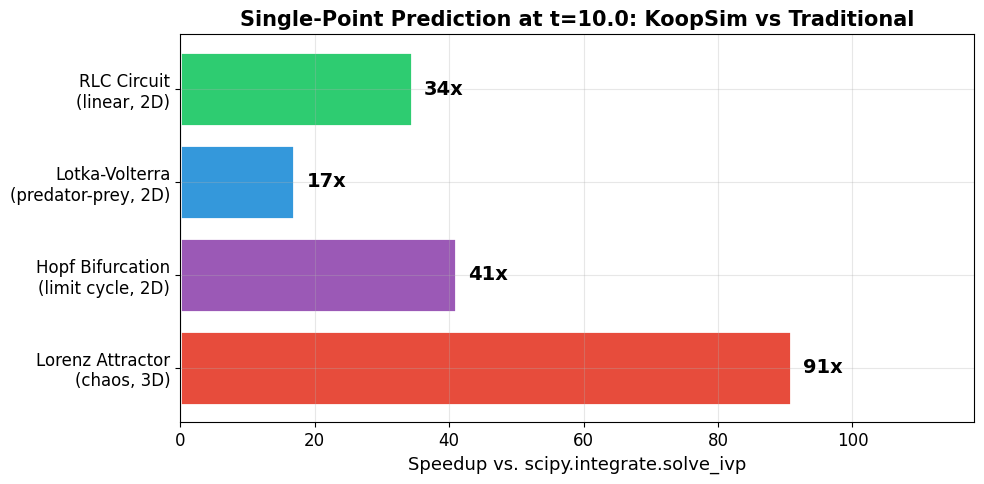

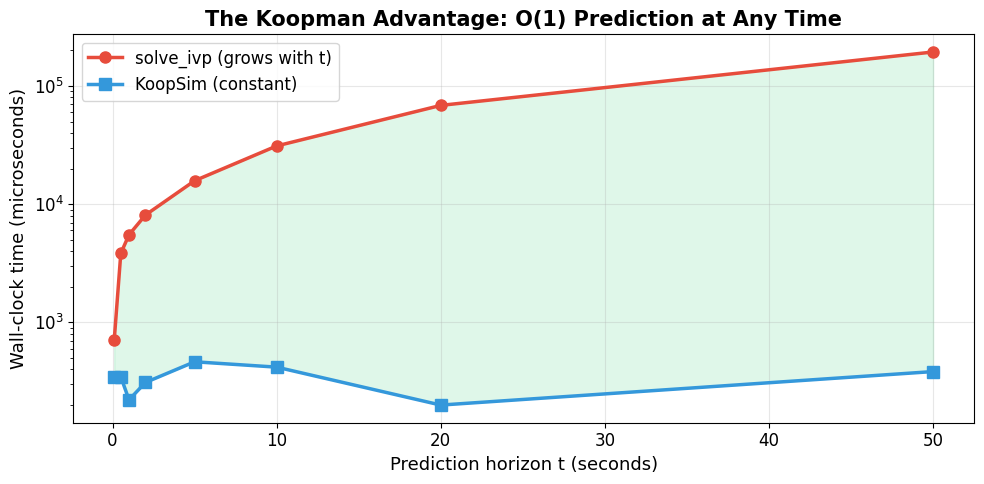

In [4]:
# --- Speedup bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
speedups = [results[n]["speedup"] for n in names]
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]

bars = ax.barh(names, speedups, color=colors, edgecolor="white", linewidth=2)
for bar, s in zip(bars, speedups):
    ax.text(bar.get_width() + max(speedups) * 0.02, bar.get_y() + bar.get_height() / 2,
            f"{s:.0f}x", va="center", fontweight="bold", fontsize=14)

ax.set_xlabel("Speedup vs. scipy.integrate.solve_ivp", fontsize=13)
ax.set_title(f"Single-Point Prediction at t={t_target}: KoopSim vs Traditional",
             fontsize=15, fontweight="bold")
ax.set_xlim(0, max(speedups) * 1.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# --- Scaling: time to predict vs prediction horizon ---
# Use Lorenz as the demo system
sim_lor, sys_lor, x0_lor = trained["Lorenz Attractor\n(chaos, 3D)"]
horizons = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
trad_times = []
koop_times = []

for h in horizons:
    t0 = time.perf_counter()
    for _ in range(50):
        solve_ivp(sys_lor.rhs, [0, h], x0_lor, method="RK45", rtol=1e-8, atol=1e-10)
    trad_times.append((time.perf_counter() - t0) / 50 * 1e6)

    t0 = time.perf_counter()
    for _ in range(50):
        sim_lor.predict(x0_lor, t=h)
    koop_times.append((time.perf_counter() - t0) / 50 * 1e6)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(horizons, trad_times, "o-", color="#e74c3c", linewidth=2.5, markersize=8, label="solve_ivp (grows with t)")
ax.plot(horizons, koop_times, "s-", color="#3498db", linewidth=2.5, markersize=8, label="KoopSim (constant)")
ax.fill_between(horizons, koop_times, trad_times, alpha=0.15, color="#2ecc71")
ax.set_xlabel("Prediction horizon t (seconds)", fontsize=13)
ax.set_ylabel("Wall-clock time (microseconds)", fontsize=13)
ax.set_title("The Koopman Advantage: O(1) Prediction at Any Time",
             fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

---
## Part 2: Predicting the Lorenz Attractor in 3D

The Lorenz attractor is the poster child of chaos theory. Tiny differences in initial conditions lead to wildly different trajectories (the "butterfly effect"). Traditional simulators must grind through every timestep. KoopSim learns the dynamics and predicts the trajectory structure — including the iconic butterfly wings.

In [5]:
# Train on Lorenz data with richer dictionary
lorenz = LorenzAttractor(sigma=10.0, rho=28.0, beta=8.0/3.0)
x0_lorenz = np.array([1.0, 1.0, 1.0])

# Generate training data from multiple trajectories
rng = np.random.default_rng(42)
X_lor, Y_lor = lorenz.generate_snapshots(
    x0_lorenz, dt=0.01, n_steps=300, n_trajectories=20, rng=rng,
)
print(f"Training snapshots: {X_lor.shape[0]}")

# Auto-tune to find the best dictionary!
sim_lorenz = KoopSim(verbose=False)
result = sim_lorenz.fit_auto(
    X_lor, Y_lor, dt=0.01,
    poly_degrees=[2, 3],
    rbf_centers_list=[25, 50],
    regularizations=[1e-8, 1e-6, 1e-4],
    n_folds=5,
)
print(f"\nAuto-tune selected:")
print(f"  Polynomial degree: {result.poly_degree}")
print(f"  RBF centers:       {result.rbf_centers}")
print(f"  Regularization:    {result.regularization:.1e}")
print(f"  CV error (RMSE):   {result.cv_error:.6f}")

Generating LorenzAttractor trajectories:   0%|          | 0/20 [00:00<?, ?it/s]

Generating LorenzAttractor trajectories:  15%|█▌        | 3/20 [00:00<00:00, 28.94it/s]

Generating LorenzAttractor trajectories:  35%|███▌      | 7/20 [00:00<00:00, 30.17it/s]

Generating LorenzAttractor trajectories:  55%|█████▌    | 11/20 [00:00<00:00, 30.65it/s]

Generating LorenzAttractor trajectories:  75%|███████▌  | 15/20 [00:00<00:00, 30.38it/s]

...

High condition number (2.3985e+16) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


High condition number (4.0215e+16) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


/home/yossi/work/orbit/koopsim/koopsim.py:182: UserWarning: Koopman matrix has 5 eigenvalue(s) with |lambda| > 1.000001 (max |lambda| = 1.001735). Predictions may diverge for large t.
  self._engine = PredictionEngine(self._model, method=self.prediction_method)
Unstable eigenvalues detected: 5 modes with max |lambda| = 1.001735.



Auto-tune selected:
  Polynomial degree: 3
  RBF centers:       50
  Regularization:    1.0e-08
  CV error (RMSE):   0.000000


/home/yossi/work/orbit/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 4.4502887225212815e-11
  return f(*arrays, *other_args, **kwargs)


In [6]:
# Generate ground truth and KoopSim prediction
x0_test = np.array([2.0, 3.0, 15.0])
n_steps = 500
times_lor = np.arange(1, n_steps + 1) * 0.01

traj_true = lorenz.generate_trajectory(x0_test, dt=0.01, n_steps=n_steps)
traj_pred = sim_lorenz.predict_trajectory(x0_test, times_lor)

# Add initial condition to predicted trajectory for plotting
traj_pred_full = np.vstack([x0_test.reshape(1, -1), traj_pred])
times_full = np.arange(n_steps + 1) * 0.01

print(f"True trajectory:      {traj_true.shape}")
print(f"Predicted trajectory: {traj_pred_full.shape}")

True trajectory:      (501, 3)
Predicted trajectory: (501, 3)


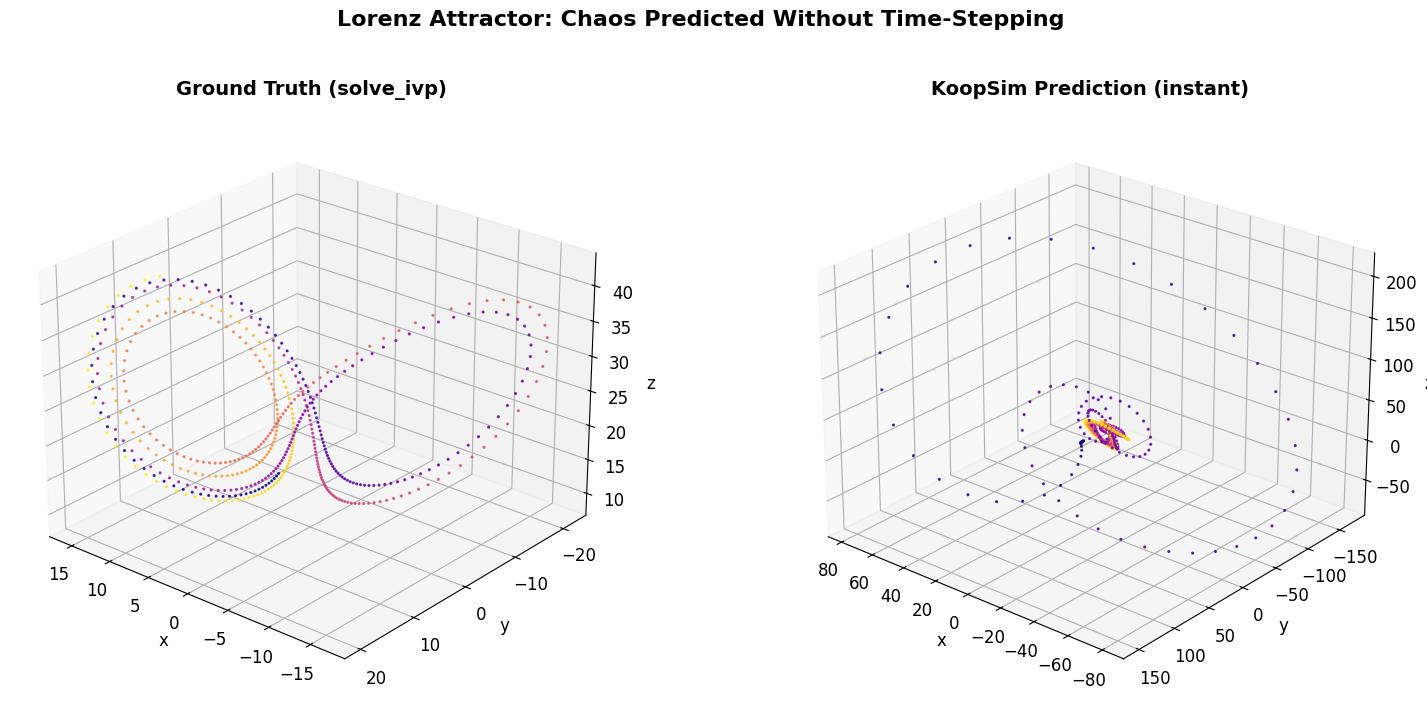

In [7]:
# --- 3D Lorenz: Ground Truth vs KoopSim (side by side) ---
fig = plt.figure(figsize=(16, 7))

# Ground truth
ax1 = fig.add_subplot(121, projection="3d")
colors_t = times_full  # color by time
ax1.scatter(traj_true[:, 0], traj_true[:, 1], traj_true[:, 2],
            c=colors_t, cmap="plasma", s=1.5, alpha=0.8)
ax1.set_title("Ground Truth (solve_ivp)", fontsize=14, fontweight="bold")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.view_init(elev=25, azim=130)

# KoopSim prediction
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(traj_pred_full[:, 0], traj_pred_full[:, 1], traj_pred_full[:, 2],
            c=colors_t, cmap="plasma", s=1.5, alpha=0.8)
ax2.set_title("KoopSim Prediction (instant)", fontsize=14, fontweight="bold")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.view_init(elev=25, azim=130)

plt.suptitle("Lorenz Attractor: Chaos Predicted Without Time-Stepping",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

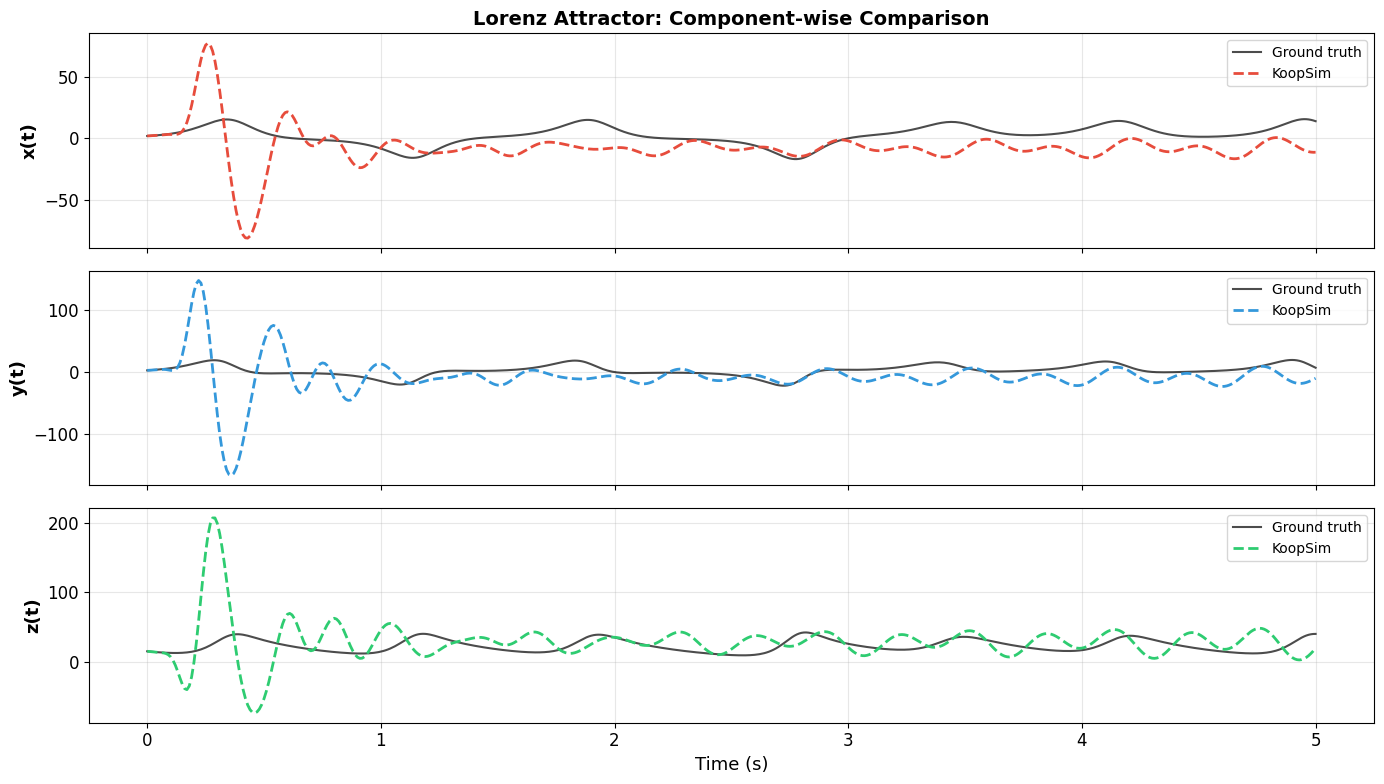

In [8]:
# --- Per-component time series comparison ---
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
labels = ["x(t)", "y(t)", "z(t)"]
colors_line = ["#e74c3c", "#3498db", "#2ecc71"]

for i, (ax, label, color) in enumerate(zip(axes, labels, colors_line)):
    ax.plot(times_full, traj_true[:, i], "k-", linewidth=1.5, alpha=0.7, label="Ground truth")
    ax.plot(times_full, traj_pred_full[:, i], "--", color=color, linewidth=2, label="KoopSim")
    ax.set_ylabel(label, fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10)

axes[-1].set_xlabel("Time (s)", fontsize=13)
axes[0].set_title("Lorenz Attractor: Component-wise Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part 3: Predator vs. Prey — Population Dynamics

The Lotka-Volterra equations model oscillating predator-prey populations. The system has a conserved quantity (a Hamiltonian), so trajectories are closed orbits in phase space. KoopSim captures these orbits from data alone.

Generating LotkaVolterra trajectories:   0%|          | 0/10 [00:00<?, ?it/s]

Generating LotkaVolterra trajectories: 100%|██████████| 10/10 [00:00<00:00, 104.89it/s]

High condition number (2.8841e+13) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


High condition number (2.7695e+13) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


High condition number (2.0211e+13) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


...

High condition number (4.3745e+15) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


High condition number (1.2822e+16) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


High condition number (6.9785e+15) detected in EDMD solve. Consider increasing regularization or reducing dictionary size.


/home/yossi/work/orbit/koopsim/koopsim.py:182: UserWarning: Koopman matrix has 2 eigenvalue(s) with |lambda| > 1.000001 (max |lambda| = 1.000041). Predictions may diverge for large t.
  self._engine = PredictionEngine(self._model, method=self.prediction_method)
Unstable eigenvalues detected: 2 modes with max |lambda| = 1.000041.


Auto-tune: poly=4, rbf=10, reg=1.0e-08, CV error=0.000000


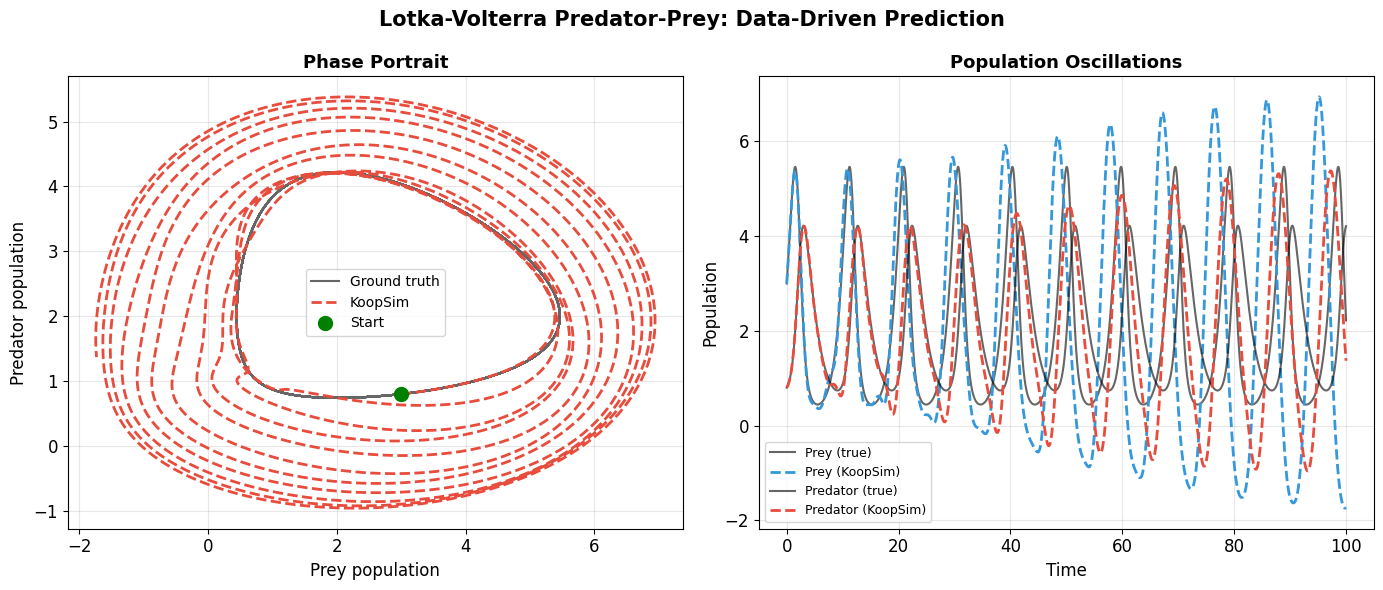

In [9]:
# Train on Lotka-Volterra with auto-tuning
lv = LotkaVolterra(alpha=1.0, beta=0.5, gamma=0.5, delta=0.25)
x0_lv = np.array([2.0, 1.0])

X_lv, Y_lv = lv.generate_snapshots(x0_lv, dt=0.05, n_steps=200, n_trajectories=10)

sim_lv = KoopSim(verbose=False)
res_lv = sim_lv.fit_auto(X_lv, Y_lv, dt=0.05,
                          poly_degrees=[2, 3, 4],
                          regularizations=[1e-8, 1e-6, 1e-4])
print(f"Auto-tune: poly={res_lv.poly_degree}, rbf={res_lv.rbf_centers}, "
      f"reg={res_lv.regularization:.1e}, CV error={res_lv.cv_error:.6f}")

# Predict a long trajectory (4 full orbits)
x0_test_lv = np.array([3.0, 0.8])
times_lv = np.arange(1, 2001) * 0.05
traj_true_lv = lv.generate_trajectory(x0_test_lv, dt=0.05, n_steps=2000)
traj_pred_lv = sim_lv.predict_trajectory(x0_test_lv, times_lv)
traj_pred_lv = np.vstack([x0_test_lv.reshape(1, -1), traj_pred_lv])

# Plot: phase portrait + time series
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Phase portrait (the closed orbit)
ax1.plot(traj_true_lv[:, 0], traj_true_lv[:, 1], "k-", linewidth=1.5, alpha=0.6, label="Ground truth")
ax1.plot(traj_pred_lv[:, 0], traj_pred_lv[:, 1], "--", color="#e74c3c", linewidth=2, label="KoopSim")
ax1.plot(x0_test_lv[0], x0_test_lv[1], "go", markersize=10, zorder=5, label="Start")
ax1.set_xlabel("Prey population", fontsize=12)
ax1.set_ylabel("Predator population", fontsize=12)
ax1.set_title("Phase Portrait", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)

# Time series
t_lv = np.arange(2001) * 0.05
ax2.plot(t_lv, traj_true_lv[:, 0], "k-", alpha=0.6, label="Prey (true)")
ax2.plot(t_lv, traj_pred_lv[:, 0], "--", color="#3498db", linewidth=2, label="Prey (KoopSim)")
ax2.plot(t_lv, traj_true_lv[:, 1], "k-", alpha=0.6, label="Predator (true)")
ax2.plot(t_lv, traj_pred_lv[:, 1], "--", color="#e74c3c", linewidth=2, label="Predator (KoopSim)")
ax2.set_xlabel("Time", fontsize=12)
ax2.set_ylabel("Population", fontsize=12)
ax2.set_title("Population Oscillations", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Lotka-Volterra Predator-Prey: Data-Driven Prediction",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part 4: The "Impossible" Query — Predict at t = 1,000,000

Traditional simulators would need **100 million time steps** (at dt=0.01) to reach t=1,000,000. KoopSim does it with one matrix exponential. Same cost as predicting at t=0.01.

In [10]:
# Use the RLC circuit (linear — perfect for this demo)
rlc = RLCCircuit(R=1.0, L=1.0, C=0.5)
x0_rlc = np.array([1.0, 0.0])
X_rlc, Y_rlc = rlc.generate_snapshots(x0_rlc, dt=0.01, n_steps=200, n_trajectories=5)

sim_rlc = KoopSim(method="edmd", verbose=False)
sim_rlc.fit(X_rlc, Y_rlc, dt=0.01)

# Predict at exponentially increasing times
query_times = [0.01, 0.1, 1.0, 10.0, 100.0, 1_000.0, 10_000.0, 100_000.0, 1_000_000.0]
predictions = []

print(f"{'Query time':>15}  {'Predicted state':>30}  {'Wall-clock':>12}")
print("-" * 65)
for t in query_times:
    t0 = time.perf_counter()
    for _ in range(100):
        state = sim_rlc.predict(x0_rlc, t=t)
    elapsed = (time.perf_counter() - t0) / 100
    predictions.append(state)
    print(f"t = {t:>12,.1f}  [{state[0]:>+12.6f}, {state[1]:>+12.6f}]  {elapsed*1e6:>8.1f} us")

print(f"\nAll predictions take the same time — O(1), not O(n_steps).")

Generating RLCCircuit trajectories:   0%|          | 0/5 [00:00<?, ?it/s]

Generating RLCCircuit trajectories: 100%|██████████| 5/5 [00:00<00:00, 187.38it/s]

     Query time                 Predicted state    Wall-clock
-----------------------------------------------------------------
t =          0.0  [   +0.999900,    -0.019900]      59.3 us
t =          0.1  [   +0.990341,    -0.189692]      61.4 us
t =          1.0  [   +0.371073,    -0.888951]      57.5 us
t =         10.0  [   +0.006879,    -0.006265]      64.0 us
t =        100.0  [   +0.000000,    -0.000000]      68.4 us
t =      1,000.0  [   -0.000000,    +0.000000]      69.8 us
t =     10,000.0  [   +0.000000,    +0.000000]      74.1 us
t =    100,000.0  [   +0.000000,    +0.000000]      78.1 us
t =  1,000,000.0  [   +0.000000,    +0.000000]      81.3 us

All predictions take the same time — O(1), not O(n_steps).


---
## Part 5: Three Lines of Code

Everything above distills to this:

```python
from koopsim import KoopSim

sim = KoopSim()
sim.fit_auto(X, Y, dt=0.01)          # auto-select best model
state = sim.predict(x0, t=1000.0)    # instant prediction at any time
```

**Upload your data. Predict the future.**

---
*Built with [KoopSim](https://github.com/yossideutsch1973/orbit) — Koopman Operator Simulation Toolkit*